Tamaño de muestra por estrato (asignación proporcional):
    Leve Moderada    Grave 
      50       30       20 

=== RESULTADOS ===
Media poblacional real:        12.218 g/dL
Media muestral simple:         12.454 g/dL
Estimador estratificado:       11.316 g/dL
Error absoluto de estimación:  0.902 g/dL


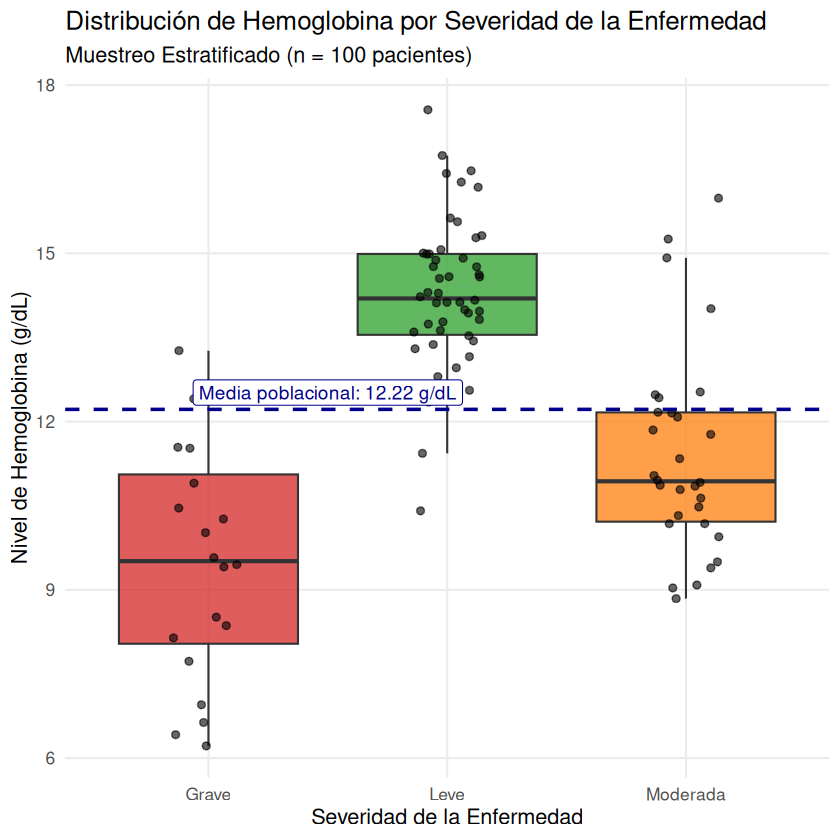

In [4]:
# ==============================================================================
# SCRIPT: Muestreo Estratificado - Niveles de Hemoglobina en Población Hospitalaria
# ==============================================================================

# Instalar y cargar ggplot2 si no está disponible
if (!requireNamespace("ggplot2", quietly = TRUE)) install.packages("ggplot2")
library(ggplot2)

set.seed(42)  # Semilla para reproducibilidad

# 1. PARÁMETROS DE LA POBLACIÓN
N_total <- 1000
estratos <- c("Leve", "Moderada", "Grave")
N_estrato <- c(Leve = 500, Moderada = 300, Grave = 200)

# Parámetros biológicos asumidos (media y desviación estándar en g/dL)
# Se refleja la distinta variabilidad biológica por severidad clínica
mu_estrato <- c(Leve = 14.0, Moderada = 11.5, Grave = 9.0)
sd_estrato <- c(Leve = 1.2, Moderada = 2.0, Grave = 2.5)

# 2. SIMULAR POBLACIÓN COMPLETA (N = 1000)
poblacion <- data.frame()
for (est in estratos) {
  n_est <- N_estrato[est]
  hemoglobina <- rnorm(n_est, mean = mu_estrato[est], sd = sd_estrato[est])
  poblacion <- rbind(poblacion, data.frame(
    ID = seq_len(n_est),
    Estrato = est,
    Hemoglobina = hemoglobina
  ))
}
poblacion$ID <- 1:nrow(poblacion)  # IDs únicos

media_poblacional <- mean(poblacion$Hemoglobina)

# 3. DISEÑO DE MUESTREO ESTRATIFICADO (n = 100)
n_total <- 100

# Asignación proporcional: n_h = n * (N_h / N)
n_muestra <- round(n_total * (N_estrato / N_total))

# Ajuste por redondeo para que la suma sea exactamente 100
diff_n <- n_total - sum(n_muestra)
n_muestra[1] <- n_muestra[1] + diff_n

cat("Tamaño de muestra por estrato (asignación proporcional):\n")
print(n_muestra)

# 4. EXTRACCIÓN DE LA MUESTRA
muestra <- data.frame()
for (est in estratos) {
  idx_estrato <- which(poblacion$Estrato == est)
  idx_muestra <- sample(idx_estrato, size = n_muestra[est], replace = FALSE)
  muestra <- rbind(muestra, poblacion[idx_muestra, ])
}

# 5. ESTIMACIÓN DE LA MEDIA POBLACIONAL
# Media muestral simple
media_muestral <- mean(muestra$Hemoglobina)

# Estimador estratificado (media ponderada por el peso de cada estrato)
# Nota: con asignación proporcional, ambos estimadores coinciden numéricamente
medias_por_estrato <- tapply(muestra$Hemoglobina, muestra$Estrato, mean)
media_estratificada <- sum((N_estrato / N_total) * medias_por_estrato)

cat("\n=== RESULTADOS ===\n")
cat(sprintf("Media poblacional real:        %.3f g/dL\n", media_poblacional))
cat(sprintf("Media muestral simple:         %.3f g/dL\n", media_muestral))
cat(sprintf("Estimador estratificado:       %.3f g/dL\n", media_estratificada))
cat(sprintf("Error absoluto de estimación:  %.3f g/dL\n", abs(media_poblacional - media_estratificada)))

# 6. GRÁFICO DE DISTRIBUCIÓN POR ESTRATOS
p <- ggplot(muestra, aes(x = Estrato, y = Hemoglobina, fill = Estrato)) +
  geom_boxplot(alpha = 0.75, outlier.shape = NA) +
  geom_jitter(width = 0.15, alpha = 0.6, size = 1.8, color = "black") +
  geom_hline(yintercept = media_poblacional, linetype = "dashed", color = "darkblue", linewidth = 1) +
  annotate("label", x = 1.5, y = media_poblacional + 0.3, 
           label = sprintf("Media poblacional: %.2f g/dL", media_poblacional),
           color = "darkblue", size = 4) +
  labs(
    title = "Distribución de Hemoglobina por Severidad de la Enfermedad",
    subtitle = paste("Muestreo Estratificado (n =", n_total, "pacientes)"),
    x = "Severidad de la Enfermedad",
    y = "Nivel de Hemoglobina (g/dL)"
  ) +
  scale_fill_manual(values = c("Leve" = "#2ca02c", "Moderada" = "#ff7f0e", "Grave" = "#d62728")) +
  theme_minimal(base_size = 13) +
  theme(legend.position = "none",
        panel.grid.minor = element_blank())

print(p)

Tamaño de muestra por estrato:
    Leve Moderada    Grave 
      50       30       20 

=== RESULTADOS ===
Media poblacional real:        12.218 g/dL
Estimador estratificado:       11.316 g/dL
Error absoluto:                0.902 g/dL


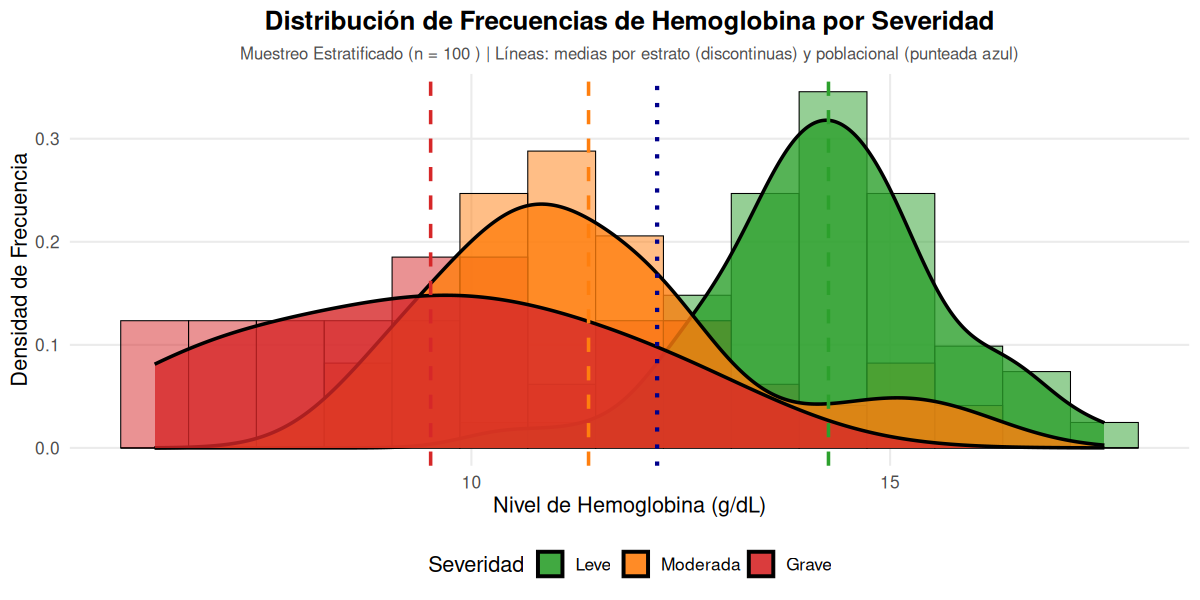


=== RESUMEN ESTADÍSTICO POR ESTRATO ===
  Estrato N_poblacion n_muestra Media_muestral SD_muestral       Min      Max
     Leve         500        50      14.263899    1.352569 10.408292 17.55904
 Moderada         300        30      11.398837    1.809005  8.843581 15.98381
    Grave         200        20       9.513172    2.125646  6.217204 13.26495


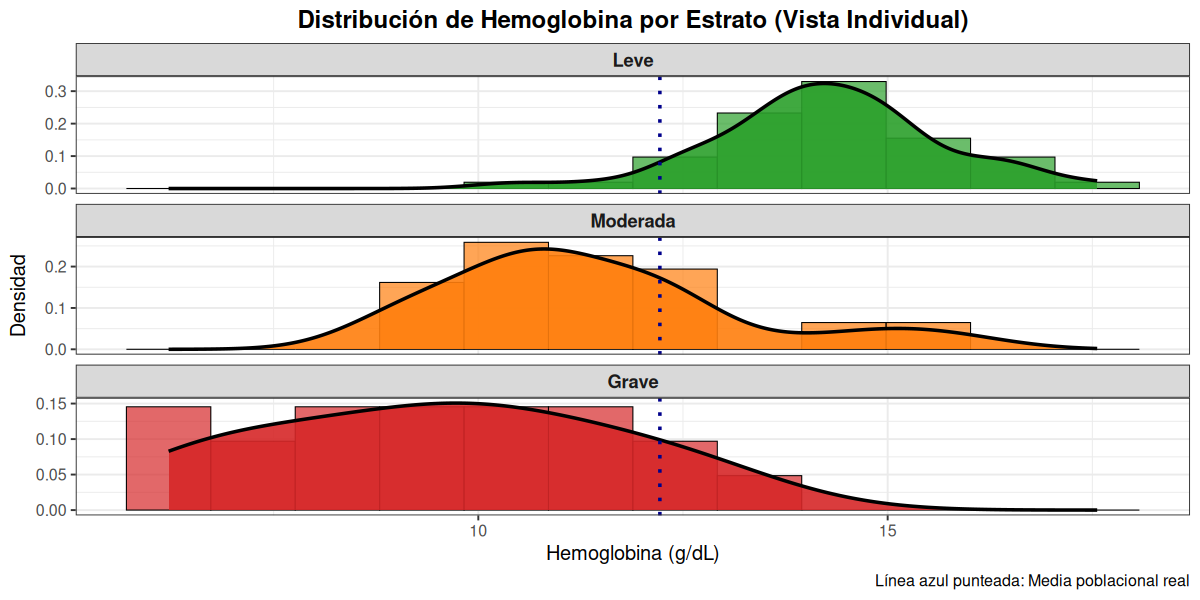

In [6]:
# ==============================================================================
# SCRIPT: Muestreo Estratificado - Gráfico de Frecuencias de Hemoglobina
# ==============================================================================

# Instalar y cargar librerías necesarias
if (!requireNamespace("ggplot2", quietly = TRUE)) install.packages("ggplot2")
if (!requireNamespace("scales", quietly = TRUE)) install.packages("scales")
library(ggplot2)
library(scales)

set.seed(42) # Reproducibilidad

# 1. PARÁMETROS DE LA POBLACIÓN
N_total <- 1000
estratos <- c("Leve", "Moderada", "Grave")
N_estrato <- c(Leve = 500, Moderada = 300, Grave = 200)

# Parámetros biológicos (media y SD en g/dL)
mu_estrato <- c(Leve = 14.0, Moderada = 11.5, Grave = 9.0)
sd_estrato <- c(Leve = 1.2, Moderada = 2.0, Grave = 2.5)

# 2. SIMULAR POBLACIÓN COMPLETA
poblacion <- data.frame()
for (est in estratos) {
    n_est <- N_estrato[est]
    hemoglobina <- rnorm(n_est, mean = mu_estrato[est], sd = sd_estrato[est])
    poblacion <- rbind(poblacion, data.frame(
        ID = seq_len(n_est),
        Estrato = est,
        Hemoglobina = hemoglobina
    ))
}
poblacion$ID <- 1:nrow(poblacion)
media_poblacional <- mean(poblacion$Hemoglobina)

# 3. MUESTREO ESTRATIFICADO (n = 100, asignación proporcional)
n_total <- 100
n_muestra <- round(n_total * (N_estrato / N_total))
diff_n <- n_total - sum(n_muestra)
n_muestra[1] <- n_muestra[1] + diff_n # Ajuste por redondeo

cat("Tamaño de muestra por estrato:\n")
print(n_muestra)

# 4. EXTRACCIÓN DE LA MUESTRA
muestra <- data.frame()
for (est in estratos) {
    idx_estrato <- which(poblacion$Estrato == est)
    idx_muestra <- sample(idx_estrato, size = n_muestra[est], replace = FALSE)
    muestra <- rbind(muestra, poblacion[idx_muestra, ])
}

# 5. ESTIMACIÓN DE LA MEDIA
medias_por_estrato <- tapply(muestra$Hemoglobina, muestra$Estrato, mean)
media_estratificada <- sum((N_estrato / N_total) * medias_por_estrato)

cat("\n=== RESULTADOS ===\n")
cat(sprintf("Media poblacional real:        %.3f g/dL\n", media_poblacional))
cat(sprintf("Estimador estratificado:       %.3f g/dL\n", media_estratificada))
cat(sprintf("Error absoluto:                %.3f g/dL\n", abs(media_poblacional - media_estratificada)))

# 6. GRÁFICO DE FRECUENCIAS (Histograma + Densidad por Estrato)

# Preparar datos: añadir densidad para suavizado
muestra$Estrato <- factor(muestra$Estrato, levels = c("Leve", "Moderada", "Grave"))

p_freq <- ggplot(muestra, aes(x = Hemoglobina, fill = Estrato)) +
    # Histograma con densidad (y = after_stat(density)) para superponer curva
    geom_histogram(aes(y = after_stat(density)),
        bins = 15,
        alpha = 0.5,
        color = "black",
        linewidth = 0.3,
        position = "identity"
    ) +
    # Curva de densidad kernel (KDE)
    geom_density(alpha = 0.8, linewidth = 1, adjust = 1.2) +
    # Líneas verticales con medias de cada estrato
    geom_vline(
        data = data.frame(
            Estrato = names(medias_por_estrato),
            Media = medias_por_estrato
        ),
        aes(xintercept = Media, color = Estrato),
        linetype = "dashed", linewidth = 1
    ) +
    # Línea de media poblacional real
    geom_vline(
        xintercept = media_poblacional,
        color = "darkblue", linetype = "dotted", linewidth = 1.2
    ) +
    # Escala de colores
    scale_fill_manual(
        values = c("Leve" = "#2ca02c", "Moderada" = "#ff7f0e", "Grave" = "#d62728"),
        name = "Severidad"
    ) +
    scale_color_manual(
        values = c("Leve" = "#2ca02c", "Moderada" = "#ff7f0e", "Grave" = "#d62728"),
        guide = "none"
    ) +
    # Etiquetas y títulos
    labs(
        title = "Distribución de Frecuencias de Hemoglobina por Severidad",
        subtitle = paste("Muestreo Estratificado (n =", n_total, ") | Líneas: medias por estrato (discontinuas) y poblacional (punteada azul)"),
        x = "Nivel de Hemoglobina (g/dL)",
        y = "Densidad de Frecuencia"
    ) +
    theme_minimal(base_size = 13) +
    theme(
        legend.position = "bottom",
        panel.grid.minor = element_blank(),
        plot.title = element_text(face = "bold", hjust = 0.5),
        plot.subtitle = element_text(size = 10, hjust = 0.5, color = "gray30")
    )

options(repr.plot.width = 10, repr.plot.height = 5) # en pulgadas
print(p_freq)

# 7. GRÁFICO ADICIONAL: Facetas separadas para mejor comparación individual
p_facet <- ggplot(muestra, aes(x = Hemoglobina, fill = Estrato)) +
    geom_histogram(aes(y = after_stat(density)),
        bins = 12,
        alpha = 0.7,
        color = "black",
        linewidth = 0.3
    ) +
    geom_density(alpha = 0.9, linewidth = 1, color = "black", adjust = 1.1) +
    geom_vline(aes(xintercept = media_poblacional),
        color = "darkblue", linetype = "dotted", linewidth = 1
    ) +
    facet_wrap(~Estrato, ncol = 1, scales = "free_y") +
    scale_fill_manual(values = c("Leve" = "#2ca02c", "Moderada" = "#ff7f0e", "Grave" = "#d62728")) +
    labs(
        title = "Distribución de Hemoglobina por Estrato (Vista Individual)",
        x = "Hemoglobina (g/dL)",
        y = "Densidad",
        caption = "Línea azul punteada: Media poblacional real"
    ) +
    theme_bw(base_size = 12) +
    theme(
        legend.position = "none",
        strip.text = element_text(face = "bold", size = 11),
        plot.title = element_text(face = "bold", hjust = 0.5)
    )

print(p_facet)

# 8. TABLA RESUMEN DE ESTADÍSTICOS MUESTRALES
resumen <- data.frame(
    Estrato = estratos,
    N_poblacion = N_estrato,
    n_muestra = n_muestra,
    Media_muestral = sapply(estratos, function(e) mean(muestra$Hemoglobina[muestra$Estrato == e])),
    SD_muestral = sapply(estratos, function(e) sd(muestra$Hemoglobina[muestra$Estrato == e])),
    Min = sapply(estratos, function(e) min(muestra$Hemoglobina[muestra$Estrato == e])),
    Max = sapply(estratos, function(e) max(muestra$Hemoglobina[muestra$Estrato == e]))
)

cat("\n=== RESUMEN ESTADÍSTICO POR ESTRATO ===\n")
print(resumen, row.names = FALSE)